In [ ]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

import jax
import jax.numpy as jnp
import numpy as np
import mujoco
from mujoco import mjx
from mujoco_playground._src import mjx_env
from ml_collections import config_dict
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from IPython import display as ipython_display

from okapi.playground.ppo import PPOConfig, train, get_obs, normalize_obs

In [25]:
# ── Constants ────────────────────────────────────────────────────────────────

BALL_SIZE = 0.15
BALL_X = 0.3
GOAL_DISTANCE = 5.5
GOAL_WIDTH = 3.66
GOAL_HEIGHT = 2.0
POST1_Y = -GOAL_WIDTH / 2
POST2_Y = GOAL_WIDTH / 2

# ── XML helpers ───────────────────────────────────────────────────────────────


def _humanoid_xml(p):
    x = 0 if p == "striker" else GOAL_DISTANCE
    f = 1 if p == "striker" else -1
    mb = f"body_{p}"  # jersey (t-shirt: torso + upper arms)
    ms = "skin"  # bare skin (head, forearms, hands, legs, feet)
    lines = [
        f'<body name="torso_{p}" pos="{x} 0 1.282" childclass="body">',
        f'  <freejoint name="root_{p}"/>',
        f'  <geom name="torso_{p}" fromto="0 -.07 0 0 .07 0" size=".07" material="{mb}"/>',
        f'  <geom name="waist_upper_{p}" fromto="{f * -0.01} -.06 -.12 {f * -0.01} .06 -.12" size=".06" material="{mb}"/>',
        f'  <body name="head_{p}" pos="0 0 .19"><geom name="head_{p}" type="sphere" size=".09" material="{ms}"/></body>',
        f'  <body name="waist_lower_{p}" pos="{f * 0.01} 0 -.26">',
        f'    <geom name="waist_lower_{p}" fromto="0 -.06 0 0 .06 0" size=".06" material="{mb}"/>',
        f'    <joint name="abdomen_z_{p}" pos="0 0 .065" axis="0 0 {f}" range="-45 45" class="joint_big_stiff"/>',
        f'    <joint name="abdomen_y_{p}" pos="0 0 .065" axis="0 {f} 0" range="-75 30" class="joint_big"/>',
        f'    <body name="pelvis_{p}" pos="0 0 -.165">',
        f'      <joint name="abdomen_x_{p}" pos="0 0 .1" axis="1 0 0" range="-35 35" class="joint_big"/>',
        f'      <geom name="butt_{p}" fromto="{f * -0.02} -.07 0 {f * -0.02} .07 0" size=".09" material="{ms}"/>',
        f'      <body name="thigh_right_{p}" pos="0 -.1 -.04">',
        f'        <joint name="hip_x_right_{p}" axis="1 0 0" class="hip_x"/>',
        f'        <joint name="hip_z_right_{p}" axis="0 0 {f}" class="hip_z"/>',
        f'        <joint name="hip_y_right_{p}" axis="0 {f} 0" class="hip_y"/>',
        f'        <geom name="thigh_right_{p}" fromto="0 0 0 0 .01 -.34" class="thigh" material="{ms}"/>',
        f'        <body name="shin_right_{p}" pos="0 .01 -.4">',
        f'          <joint name="knee_right_{p}" axis="0 {-f} 0" class="knee"/>',
        f'          <geom name="shin_right_{p}" class="shin" material="{ms}"/>',
        f'          <body name="foot_right_{p}" pos="0 0 -.39">',
        f'            <joint name="ankle_y_right_{p}" axis="0 {f} 0" class="ankle_y"/>',
        f'            <joint name="ankle_x_right_{p}" axis="1 0 {f * 0.5}" class="ankle_x"/>',
        f'            <geom name="foot1_right_{p}" class="foot1_{p}" material="{ms}"/>',
        f'            <geom name="foot2_right_{p}" class="foot2_{p}" material="{ms}"/>',
        "          </body>",
        "        </body>",
        "      </body>",
        f'      <body name="thigh_left_{p}" pos="0 .1 -.04">',
        f'        <joint name="hip_x_left_{p}" axis="-1 0 0" class="hip_x"/>',
        f'        <joint name="hip_z_left_{p}" axis="0 0 {-f}" class="hip_z"/>',
        f'        <joint name="hip_y_left_{p}" axis="0 {f} 0" class="hip_y"/>',
        f'        <geom name="thigh_left_{p}" fromto="0 0 0 0 -.01 -.34" class="thigh" material="{ms}"/>',
        f'        <body name="shin_left_{p}" pos="0 -.01 -.4">',
        f'          <joint name="knee_left_{p}" axis="0 {-f} 0" class="knee"/>',
        f'          <geom name="shin_left_{p}" fromto="0 0 0 0 0 -.3" class="shin" material="{ms}"/>',
        f'          <body name="foot_left_{p}" pos="0 0 -.39">',
        f'            <joint name="ankle_y_left_{p}" axis="0 {f} 0" class="ankle_y"/>',
        f'            <joint name="ankle_x_left_{p}" axis="-1 0 {-f * 0.5}" class="ankle_x"/>',
        f'            <geom name="foot1_left_{p}" class="foot1_{p}" material="{ms}"/>',
        f'            <geom name="foot2_left_{p}" class="foot2_{p}" material="{ms}"/>',
        "          </body>",
        "        </body>",
        "      </body>",
        "    </body>",
        "  </body>",
        f'  <body name="upper_arm_right_{p}" pos="0 -.17 .06">',
        f'    <joint name="shoulder1_right_{p}" axis="2 {f} {f}" class="shoulder"/>',
        f'    <joint name="shoulder2_right_{p}" axis="0 {-f} {f}" class="shoulder"/>',
        f'    <geom name="upper_arm_right_{p}" fromto="0 0 0 {f * 0.16} -.16 -.16" class="arm_upper" material="{mb}"/>',
        f'    <body name="lower_arm_right_{p}" pos="{f * 0.18} -.18 -.18">',
        f'      <joint name="elbow_right_{p}" axis="0 {-f} {f}" class="elbow"/>',
        f'      <geom name="lower_arm_right_{p}" fromto="{f * 0.01} .01 .01 {f * 0.17} .17 .17" class="arm_lower" material="{ms}"/>',
        f'      <body name="hand_right_{p}" pos="{f * 0.18} .18 .18">',
        f'        <geom name="hand_right_{p}" zaxis="1 {f} 1" class="hand" material="{ms}"/>',
        "      </body>",
        "    </body>",
        "  </body>",
        f'  <body name="upper_arm_left_{p}" pos="0 .17 .06">',
        f'    <joint name="shoulder1_left_{p}" axis="-2 {f} {-f}" class="shoulder"/>',
        f'    <joint name="shoulder2_left_{p}" axis="0 {-f} {-f}" class="shoulder"/>',
        f'    <geom name="upper_arm_left_{p}" fromto="0 0 0 {f * 0.16} .16 -.16" class="arm_upper" material="{mb}"/>',
        f'    <body name="lower_arm_left_{p}" pos="{f * 0.18} .18 -.18">',
        f'      <joint name="elbow_left_{p}" axis="0 {-f} {-f}" class="elbow"/>',
        f'      <geom name="lower_arm_left_{p}" fromto="{f * 0.01} -.01 .01 {f * 0.17} -.17 .17" class="arm_lower" material="{ms}"/>',
        f'      <body name="hand_left_{p}" pos="{f * 0.18} -.18 .18">',
        f'        <geom name="hand_left_{p}" zaxis="1 {-f} 1" class="hand" material="{ms}"/>',
        "      </body>",
        "    </body>",
        "  </body>",
        "</body>",
    ]
    return "\n    ".join(lines)


def _contact_xml(p):
    extra = ""
    if p == "keeper":
        extra = (
            f'\n        <pair geom1="torso_{p}" geom2="ball"/>'
            f'\n        <pair geom1="waist_upper_{p}" geom2="ball"/>'
            f'\n        <pair geom1="head_{p}" geom2="ball"/>'
            f'\n        <pair geom1="waist_lower_{p}" geom2="ball"/>'
            f'\n        <pair geom1="butt_{p}" geom2="ball"/>'
            f'\n        <pair geom1="thigh_right_{p}" geom2="ball"/>'
            f'\n        <pair geom1="shin_right_{p}" geom2="ball"/>'
            f'\n        <pair geom1="foot1_right_{p}" geom2="ball"/>'
            f'\n        <pair geom1="foot2_right_{p}" geom2="ball"/>'
            f'\n        <pair geom1="thigh_left_{p}" geom2="ball"/>'
            f'\n        <pair geom1="shin_left_{p}" geom2="ball"/>'
            f'\n        <pair geom1="upper_arm_right_{p}" geom2="ball"/>'
            f'\n        <pair geom1="lower_arm_right_{p}" geom2="ball"/>'
            f'\n        <pair geom1="hand_right_{p}" geom2="ball"/>'
            f'\n        <pair geom1="upper_arm_left_{p}" geom2="ball"/>'
            f'\n        <pair geom1="lower_arm_left_{p}" geom2="ball"/>'
            f'\n        <pair geom1="hand_left_{p}" geom2="ball"/>'
        )
    return (
        f'\n    <exclude body1="waist_lower_{p}" body2="thigh_right_{p}"/>'
        f'\n    <exclude body1="waist_lower_{p}" body2="thigh_left_{p}"/>'
        f'\n    <pair geom1="foot1_left_{p}" geom2="floor"/>'
        f'\n    <pair geom1="foot1_right_{p}" geom2="floor"/>'
        f'\n    <pair geom1="foot2_left_{p}" geom2="floor"/>'
        f'\n    <pair geom1="foot2_right_{p}" geom2="floor"/>'
        f'\n    <pair geom1="foot1_left_{p}" geom2="ball"/>'
        f'\n    <pair geom1="foot2_left_{p}" geom2="ball"/>'
        f'\n    <pair geom1="shin_left_{p}" geom2="ball"/>{extra}'
    )


def _actuator_xml(p):
    motors = [
        ("abdomen_y", "40"),
        ("abdomen_z", "40"),
        ("abdomen_x", "40"),
        ("hip_x_right", "40"),
        ("hip_z_right", "40"),
        ("hip_y_right", "120"),
        ("knee_right", "80"),
        ("ankle_x_right", "20"),
        ("ankle_y_right", "20"),
        ("hip_x_left", "40"),
        ("hip_z_left", "40"),
        ("hip_y_left", "120"),
        ("knee_left", "80"),
        ("ankle_x_left", "20"),
        ("ankle_y_left", "20"),
        ("shoulder1_right", "20"),
        ("shoulder2_right", "20"),
        ("elbow_right", "40"),
        ("shoulder1_left", "20"),
        ("shoulder2_left", "20"),
        ("elbow_left", "40"),
    ]
    return "\n    ".join(
        f'<motor name="{n}_{p}" gear="{g}" joint="{n}_{p}"/>' for n, g in motors
    )


_XML = (
    '<mujoco model="Penalties">\n'
    '  <option timestep="0.005" iterations="1" ls_iterations="4">\n'
    '    <flag eulerdamp="disable"/>\n'
    "  </option>\n"
    "  <visual>\n"
    '    <map force="0.1" zfar="50" znear="0.1"/>\n'
    '    <rgba haze="0.15 0.25 0.35 1"/>\n'
    '    <global offwidth="1280" offheight="720" elevation="-20" azimuth="120"/>\n'
    '    <quality shadowsize="2048" offsamples="4"/>\n'
    "  </visual>\n"
    f'  <statistic center="{GOAL_DISTANCE / 2} 0 1" extent="8"/>\n'
    "  <asset>\n"
    '    <texture type="skybox" builtin="gradient" rgb1=".4 .6 .8" rgb2=".1 .2 .4" width="32" height="512"/>\n'
    '    <texture name="body" type="cube" builtin="flat" mark="cross" width="128" height="128"\n'
    '             rgb1="0.8 0.6 0.4" rgb2="0.8 0.6 0.4" markrgb="1 1 1" random="0.01"/>\n'
    '    <material name="body" texture="body" texuniform="true" rgba="0.8 0.6 .4 1"/>\n'
    '    <material name="body_striker" rgba="0.1 0.1 0.8 1"/>\n'
    '    <material name="body_keeper"  rgba="0.8 0.1 0.1 1"/>\n'
    '    <material name="skin"         rgba="0.7 0.5 0.3 1"/>\n'
    "    <!-- wide pitch stripes: many x-repeats, few y-repeats → long bands along pitch width -->\n"
    '    <texture name="texplane" type="2d" builtin="checker"\n'
    '             rgb1=".24 .48 .14" rgb2=".32 .58 .20" width="512" height="512"/>\n'
    '    <material name="MatPlane" reflectance="0.1" texture="texplane"\n'
    '              texrepeat="5 1" texuniform="true"/>\n'
    '    <texture name="texball" type="cube" builtin="checker"\n'
    '             rgb1="0.1 0.1 0.1" rgb2="0.95 0.95 0.95" width="128" height="128"/>\n'
    '    <material name="ball" texture="texball" texuniform="true" rgba="1 1 1 1"/>\n'
    "  </asset>\n"
    "  <default>\n"
    f'    <default class="ball">\n'
    f'      <geom type="sphere" material="ball" size="{BALL_SIZE}" mass="0.045"\n'
    '            friction="0.7 0.005 0.0001" solref="0.02 1.0" solimp="0.9 0.99 0.01"/>\n'
    "    </default>\n"
    '    <motor ctrlrange="-1 1" ctrllimited="true"/>\n'
    '    <default class="body">\n'
    '      <geom type="capsule" condim="3" friction=".7" solimp=".9 .99 .003" solref=".015 1"\n'
    '            material="body" contype="0" conaffinity="0"/>\n'
    '      <default class="thigh"><geom size=".06"/></default>\n'
    '      <default class="shin"><geom fromto="0 0 0 0 0 -.3" size=".049"/></default>\n'
    '      <default class="foot">\n'
    '        <geom size=".027"/>\n'
    '        <default class="foot1_striker"><geom fromto="-.07 -.01 0 .14 -.03 0"/></default>\n'
    '        <default class="foot2_striker"><geom fromto="-.07  .01 0 .14  .03 0"/></default>\n'
    '        <default class="foot1_keeper"><geom fromto="-.14 -.03 0 .07 -.01 0"/></default>\n'
    '        <default class="foot2_keeper"><geom fromto="-.14  .03 0 .07  .01 0"/></default>\n'
    "      </default>\n"
    '      <default class="arm_upper"><geom size=".04"/></default>\n'
    '      <default class="arm_lower"><geom size=".031"/></default>\n'
    '      <default class="hand"><geom type="sphere" size=".04"/></default>\n'
    '      <joint type="hinge" damping=".2" stiffness="1" armature=".01" limited="true"\n'
    '             solimplimit="0 .99 .01"/>\n'
    '      <default class="joint_big">\n'
    '        <joint damping="5" stiffness="10"/>\n'
    '        <default class="hip_x"><joint range="-30 10"/></default>\n'
    '        <default class="hip_z"><joint range="-60 35"/></default>\n'
    '        <default class="hip_y"><joint axis="0 1 0" range="-150 20"/></default>\n'
    '        <default class="joint_big_stiff"><joint stiffness="20"/></default>\n'
    "      </default>\n"
    '      <default class="knee"><joint pos="0 0 .02" axis="0 -1 0" range="-160 2"/></default>\n'
    '      <default class="ankle">\n'
    '        <joint range="-50 50"/>\n'
    '        <default class="ankle_y"><joint pos="0 0 .08" axis="0 1 0" stiffness="6"/></default>\n'
    '        <default class="ankle_x"><joint pos="0 0 .04" stiffness="3"/></default>\n'
    "      </default>\n"
    '      <default class="shoulder"><joint range="-85 60"/></default>\n'
    '      <default class="elbow"><joint range="-100 50" stiffness="0"/></default>\n'
    "    </default>\n"
    "  </default>\n"
    "  <worldbody>\n"
    f'    <light directional="true" diffuse=".8 .8 .8" pos="{GOAL_DISTANCE / 2} 0 15" dir="0 0 -10"/>\n'
    f'    <geom name="floor" type="plane" size="{GOAL_DISTANCE * 1.5} 6 .5" material="MatPlane" condim="3"/>\n'
    f'    <camera name="back_striker" pos="-4.5 -2 2.5" xyaxes="2 -5 0 1 0 3" mode="fixed"/>\n'
    f'    <camera name="back_keeper" pos="{GOAL_DISTANCE + 4.5} -2 2.5" xyaxes="-2 -5 0 1 0 3" mode="fixed"/>\n'
    f"    {_humanoid_xml('striker')}\n"
    f"    {_humanoid_xml('keeper')}\n"
    f'    <body name="post1" pos="{GOAL_DISTANCE} {POST1_Y} 0">\n'
    f'      <geom name="post_geom1" type="box" size="0.05 0.05 {GOAL_HEIGHT}" rgba="1 1 1 1" contype="1" conaffinity="1"/>\n'
    "    </body>\n"
    f'    <body name="post2" pos="{GOAL_DISTANCE} {POST2_Y} 0">\n'
    f'      <geom name="post_geom2" type="box" size="0.05 0.05 {GOAL_HEIGHT}" rgba="1 1 1 1" contype="1" conaffinity="1"/>\n'
    "    </body>\n"
    f'    <body name="crossbar" pos="{GOAL_DISTANCE} 0 {GOAL_HEIGHT}">\n'
    f'      <geom name="bar_geom" type="box" size="0.05 {GOAL_WIDTH / 2} 0.05" rgba="1 1 1 1" contype="1" conaffinity="1"/>\n'
    "    </body>\n"
    f'    <body name="ball" pos="{BALL_X} 0 {BALL_SIZE}" quat="0.632456 -0.632456 0.316228 0.316228">\n'
    "      <freejoint/>\n"
    '      <geom class="ball" name="ball"/>\n'
    "    </body>\n"
    "  </worldbody>\n"
    "  <contact>\n"
    f"    {_contact_xml('striker')}\n"
    f"    {_contact_xml('keeper')}\n"
    '    <pair geom1="post_geom1" geom2="ball"/>\n'
    '    <pair geom1="post_geom2" geom2="ball"/>\n'
    '    <pair geom1="bar_geom"   geom2="ball"/>\n'
    "  </contact>\n"
    "  <actuator>\n"
    f"    {_actuator_xml('striker')}\n"
    f"    {_actuator_xml('keeper')}\n"
    "  </actuator>\n"
    "</mujoco>"
)

# ── Step helper ───────────────────────────────────────────────────────────────


def _mjx_step(mjx_model, data, action, n_substeps):
    def single_step(data, _):
        data = data.replace(ctrl=action)
        data = mjx.step(mjx_model, data)
        # clamp velocities to prevent NaN/physics explosion
        qvel = jnp.clip(data.qvel, -100.0, 100.0)
        return data.replace(qvel=qvel), None

    return jax.lax.scan(single_step, data, (), n_substeps)[0]


def _penalties_config():
    return config_dict.create(
        ctrl_dt=0.025,
        sim_dt=0.005,
        impl="jax",
        nconmax=300,
        njmax=300,
    )


class PenaltiesEnv(mjx_env.MjxEnv):
    """Two-humanoid penalty kick environment.

    training='striker': trains the shooter (keeper uses zero actions).
    training='keeper':  trains the goalkeeper (striker_fn provides actions).
    striker_fn: callable(obs_dict) -> array[21], required when training='keeper'.
    """

    # qpos layout: striker(28) | keeper(28) | ball(7) = 63 total
    _STRIKER_Z_IDX = 2
    _KEEPER_Z_IDX = 30  # 28 + 2
    _BALL_XYZ_SLICE = slice(56, 59)

    def __init__(
        self, training="striker", striker_fn=None, config=None, config_overrides=None
    ):
        super().__init__(config or _penalties_config(), config_overrides)
        self._training = training
        self._striker_fn = striker_fn
        self._mj_model = mujoco.MjModel.from_xml_string(_XML)
        self._mj_model.opt.solver = mujoco.mjtSolver.mjSOL_CG
        self._mj_model.opt.iterations = 6
        self._mj_model.opt.ls_iterations = 6
        self._mj_model.opt.timestep = self.sim_dt
        self._mjx_model = mjx.put_model(self._mj_model, impl=self._config.impl)
        self._striker_torso_id = self._mj_model.body("torso_striker").id
        self._keeper_torso_id = self._mj_model.body("torso_keeper").id
        self._keeper_hand_right_id = self._mj_model.body("hand_right_keeper").id
        self._keeper_hand_left_id = self._mj_model.body("hand_left_keeper").id

    def reset(self, rng: jax.Array) -> mjx_env.State:
        rng, r1, r2 = jax.random.split(rng, 3)
        data = mjx.make_data(self.mj_model, impl=self._config.impl)
        ns = 1e-2
        n_hum_q = self.mj_model.nq - 7
        n_hum_dq = self.mj_model.nv - 6
        noise_q = jax.random.uniform(r1, (n_hum_q,), minval=-ns, maxval=ns)
        noise_v = jax.random.uniform(r2, (n_hum_dq,), minval=-ns, maxval=ns)
        qpos = data.qpos.at[:n_hum_q].add(noise_q)
        qvel = data.qvel.at[:n_hum_dq].set(noise_v)
        data = data.replace(qpos=qpos, qvel=qvel)
        data = mjx.forward(self.mjx_model, data)
        metrics = {
            "reward/ball": jnp.zeros(()),
            "reward/velocity": jnp.zeros(()),
            "reward/hands": jnp.zeros(()),
            "reward/ctrl": jnp.zeros(()),
            "goals": jnp.zeros(()),
        }
        info = {"rng": rng}
        obs = self._get_obs(data, info)
        return mjx_env.State(data, obs, jnp.zeros(()), jnp.zeros(()), metrics, info)

    def step(self, state: mjx_env.State, action: jax.Array) -> mjx_env.State:
        if self._training == "striker":
            full_ctrl = jnp.concatenate([action, jnp.zeros(21)])
        else:
            striker_act = self._striker_fn(state.obs)
            full_ctrl = jnp.concatenate([striker_act, action])

        data0 = state.data
        data = _mjx_step(self.mjx_model, data0, full_ctrl, self.n_substeps)

        ball_pos0 = data0.qpos[self._BALL_XYZ_SLICE]
        ball_pos = data.qpos[self._BALL_XYZ_SLICE]

        is_goal = (
            (ball_pos0[0] < GOAL_DISTANCE)
            & (ball_pos[0] >= GOAL_DISTANCE)
            & (jnp.abs(ball_pos[1]) < GOAL_WIDTH / 2)
            & (ball_pos[2] < GOAL_HEIGHT + 0.15)
        ).astype(jnp.float32)

        if self._training == "striker":
            reward, done, metrics = self._striker_reward(data0, data, action, is_goal)
        else:
            reward, done, metrics = self._keeper_reward(data, action, is_goal)

        info = {**state.info}
        obs = self._get_obs(data, info)
        return mjx_env.State(data, obs, reward, done, metrics, info)

    def _striker_reward(self, data0, data, action, is_goal):
        ball_pos0 = data0.qpos[self._BALL_XYZ_SLICE]
        ball_pos = data.qpos[self._BALL_XYZ_SLICE]
        ball_x = ball_pos[0]
        ball_z = ball_pos[2]
        striker_z = data.qpos[self._STRIKER_Z_IDX]

        is_healthy = jnp.where(striker_z < 1.0, 0.0, 1.0)
        is_healthy = jnp.where(striker_z > 3.0, 0.0, is_healthy)
        is_healthy = jnp.where(ball_z < 0.0, 0.0, is_healthy)
        is_healthy = jnp.where(ball_z > GOAL_HEIGHT, 0.0, is_healthy)
        is_healthy = jnp.where(ball_x > GOAL_DISTANCE * 1.5, 0.0, is_healthy)

        ctrl_cost = 0.1 * jnp.sum(jnp.square(action))

        velocity_x = (ball_pos[0] - ball_pos0[0]) / self._config.ctrl_dt
        distance_goal = jnp.abs(GOAL_DISTANCE - ball_x)

        ball_dist_rwd = jnp.where(
            ball_x > GOAL_DISTANCE, 0.0, 5.0 * (1.0 - distance_goal / GOAL_DISTANCE)
        )
        ball_vel_rwd = jnp.where(ball_x > GOAL_DISTANCE, 0.0, 5.0 * velocity_x)

        goal_rwd = 1000.0 * is_goal
        healthy_rwd = 1.0

        reward = ball_dist_rwd + ball_vel_rwd + healthy_rwd - ctrl_cost + goal_rwd
        done = 1.0 - is_healthy
        metrics = {
            "reward/ball": ball_dist_rwd,
            "reward/velocity": ball_vel_rwd,
            "reward/hands": jnp.zeros(()),
            "reward/ctrl": -ctrl_cost,
            "goals": is_goal,
        }
        return reward, done, metrics

    def _keeper_reward(self, data, action, is_goal):
        ball_pos = data.qpos[self._BALL_XYZ_SLICE]
        ball_x = ball_pos[0]
        keeper_z = data.qpos[self._KEEPER_Z_IDX]

        is_healthy = jnp.where(keeper_z < 1.0, 0.0, 1.0)
        is_healthy = jnp.where(keeper_z > 3.0, 0.0, is_healthy)
        is_healthy = jnp.where(ball_x > GOAL_DISTANCE * 1.5, 0.0, is_healthy)

        ctrl_cost = 0.1 * jnp.sum(jnp.square(action))

        rh_pos = data.xpos[self._keeper_hand_right_id]
        lh_pos = data.xpos[self._keeper_hand_left_id]

        dist_right = jnp.sqrt(
            jnp.square(ball_pos[1] - rh_pos[1]) + jnp.square(ball_pos[2] - rh_pos[2])
        )
        dist_left = jnp.sqrt(
            jnp.square(ball_pos[1] - lh_pos[1]) + jnp.square(ball_pos[2] - lh_pos[2])
        )
        dist_hands = (dist_right + dist_left) / 2.0

        hands_rwd = 5.0 * (1.0 - dist_hands / GOAL_WIDTH)
        goal_pen = -1000.0 * is_goal

        reward = hands_rwd - ctrl_cost + goal_pen
        done = 1.0 - is_healthy
        metrics = {
            "reward/ball": jnp.zeros(()),
            "reward/velocity": jnp.zeros(()),
            "reward/hands": hands_rwd,
            "reward/ctrl": -ctrl_cost,
            "goals": is_goal,
        }
        return reward, done, metrics

    def _get_obs(self, data: mjx.Data, info: dict) -> dict:
        obs = jnp.concatenate(
            [
                data.qpos[2:],  # 61 dims
                data.qvel,  # 60 dims
                data.xpos[1:].ravel(),  # 36*3 = 108 dims
                data.xmat[1:].ravel(),  # 36*9 = 324 dims
                data.qfrc_actuator,  # 42   dims  => total 595
            ]
        )
        return {"state": obs, "privileged_state": obs}

    @property
    def xml_path(self) -> str:
        return ""

    @property
    def action_size(self) -> int:
        return 21

    @property
    def mj_model(self) -> mujoco.MjModel:
        return self._mj_model

    @property
    def mjx_model(self) -> mjx.Model:
        return self._mjx_model


# Smoke-test
_env = PenaltiesEnv(training="striker")
_s0 = jax.jit(_env.reset)(jax.random.key(0))
_s1 = jax.jit(_env.step)(_s0, jnp.zeros(_env.action_size))
print(f"nq={_env.mj_model.nq}  nv={_env.mj_model.nv}  nu={_env.mj_model.nu}")
print(f"obs shape: {_s0.obs['state'].shape}   action_size: {_env.action_size}")
print(f"step reward: {float(_s1.reward):.3f}   done: {float(_s1.done):.0f}")

nq=63  nv=60  nu=42
obs shape: (613,)   action_size: 21
step reward: 1.273   done: 0


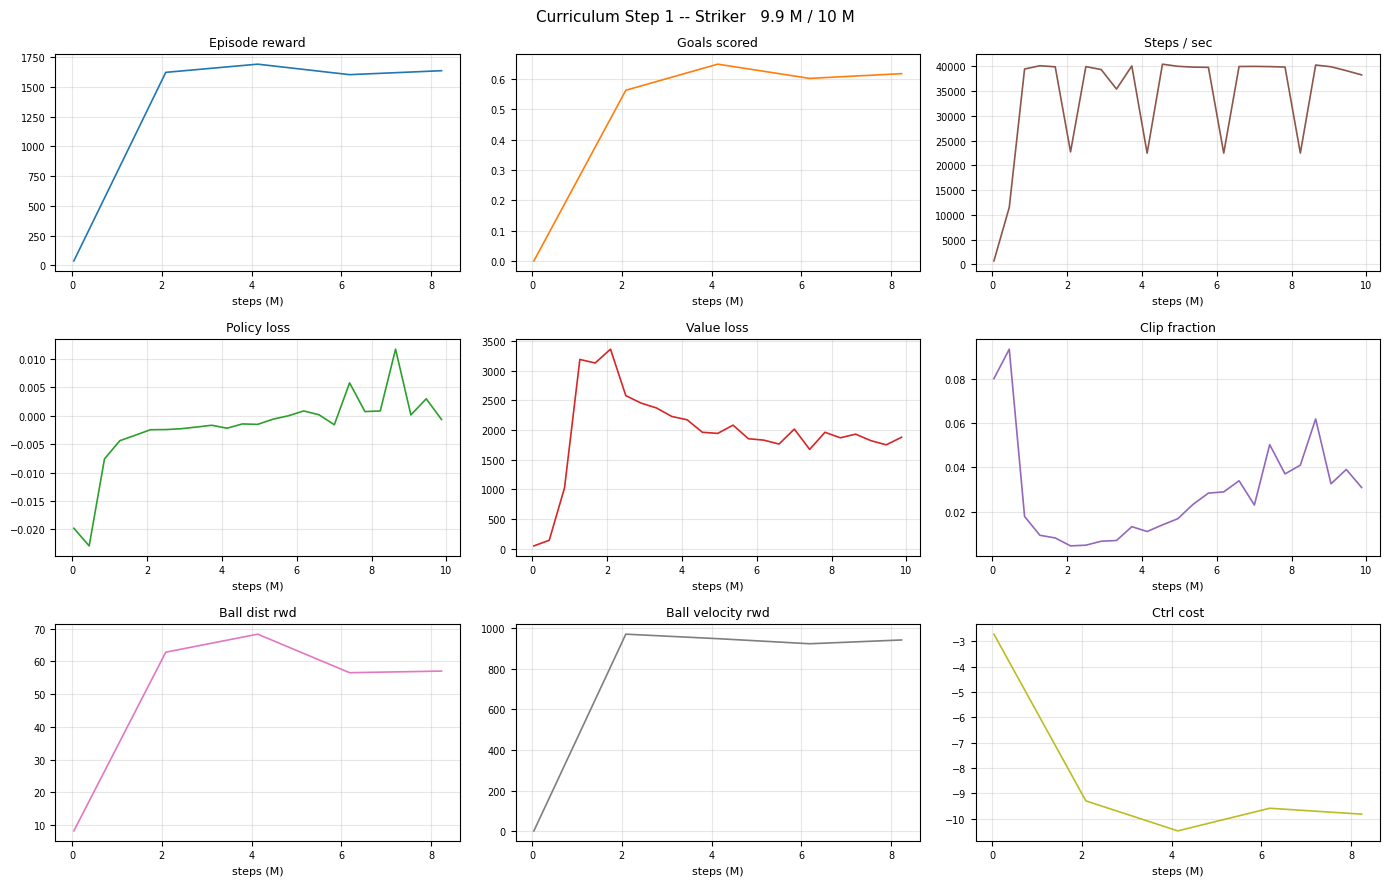

In [26]:
# =====================================
# Curriculum Step 1 -- Train Striker
# Keeper is passive (zero actions).
# =====================================

cfg_striker = PPOConfig(
    env_id="Penalties-Striker",
    num_envs=2048,
    total_timesteps=10_000_000,
    num_steps=20,
    num_minibatches=32,
    update_epochs=8,
    learning_rate=1e-4,
    gamma=0.9,
    gae_lambda=0.95,
    clip_coef=0.3,
    ent_coef=1e-3,
    vf_coef=0.5,
    max_grad_norm=1.0,
    reward_scaling=1.0,
    norm_adv=True,
    actor_hidden_sizes=[64, 64, 64, 64],
    critic_hidden_sizes=[256, 256, 256, 256, 256],
    policy_obs_key="state",
    value_obs_key="privileged_state",
    log_frequency=10,
    eval_frequency=50,
    eval_episodes=128,
    use_checkpointing=False,
    use_wandb=False,
    verbose=False,
    progress_bar=False,
    seed=42,
)

PLOT_KEYS_STRIKER = [
    ("training/episode_reward", "Episode reward", "C0"),
    ("eval/goals", "Goals scored", "C1"),
    ("time/sps", "Steps / sec", "C5"),
    ("loss/policy", "Policy loss", "C2"),
    ("loss/value", "Value loss", "C3"),
    ("diagnostics/clip_frac", "Clip fraction", "C4"),
    ("eval/reward/ball", "Ball dist rwd", "C6"),
    ("eval/reward/velocity", "Ball velocity rwd", "C7"),
    ("eval/reward/ctrl", "Ctrl cost", "C8"),
]

fig_s, axes_s = plt.subplots(3, 3, figsize=(14, 9))
axes_s = axes_s.ravel()
for ax, (_, label, _c) in zip(axes_s, PLOT_KEYS_STRIKER):
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("steps (M)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
fig_s.suptitle("Curriculum Step 1 -- Striker", fontsize=11)
fig_s.tight_layout()

logs_s = []


def log_callback_striker(log, step):
    logs_s.append({"step": step, **log})
    if len(logs_s) < 2:
        return
    steps_m = [d["step"] / 1e6 for d in logs_s]
    for ax, (key, label, color) in zip(axes_s, PLOT_KEYS_STRIKER):
        vals = [d.get(key) for d in logs_s]
        valid = [(s, v) for s, v in zip(steps_m, vals) if v is not None]
        if len(valid) < 2:
            continue
        xs, ys = zip(*valid)
        ax.cla()
        ax.plot(xs, ys, color=color, linewidth=1.2)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel("steps (M)", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
    fig_s.suptitle(
        f"Curriculum Step 1 -- Striker   {step / 1e6:.1f} M / {cfg_striker.total_timesteps / 1e6:.0f} M",
        fontsize=11,
    )
    fig_s.tight_layout()
    ipython_display.clear_output(wait=True)
    ipython_display.display(fig_s)


striker_model, striker_opt, striker_actor_stats, striker_critic_stats = train(
    cfg_striker,
    env_factory=lambda: PenaltiesEnv(training="striker"),
    log_callback=log_callback_striker,
)

plt.savefig("penalties_striker_training.png", dpi=120)
plt.close(fig_s)

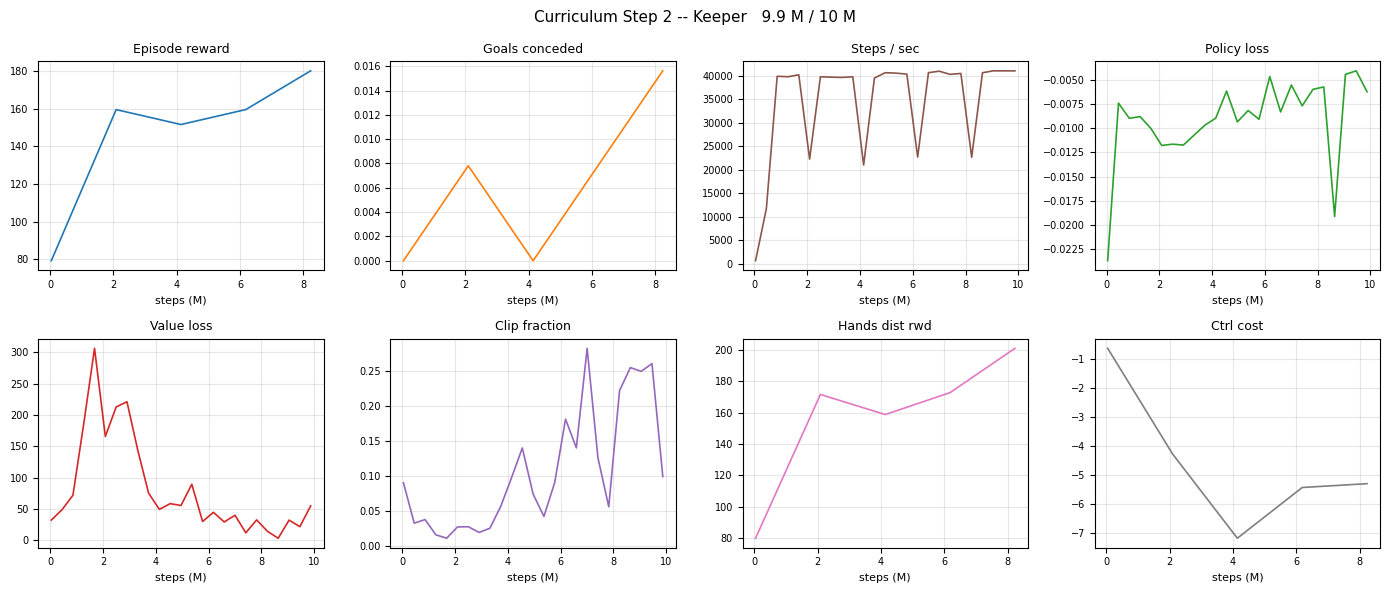

In [27]:
# =====================================
# Curriculum Step 2 -- Train Keeper
# Striker uses frozen policy from Step 1.
# =====================================

# Frozen striker policy (pure JAX closure -- called inside env.step via jit/vmap)
def frozen_striker_fn(obs_dict):
    norm = normalize_obs(
        get_obs(obs_dict, cfg_striker.policy_obs_key), striker_actor_stats
    )
    dist, _ = striker_model(norm, norm)
    return dist.mode  # deterministic


cfg_keeper = PPOConfig(
    env_id="Penalties-Keeper",
    num_envs=2048,
    total_timesteps=10_000_000,
    num_steps=20,
    num_minibatches=32,
    update_epochs=8,
    learning_rate=1e-4,
    gamma=0.9,
    gae_lambda=0.95,
    clip_coef=0.3,
    ent_coef=1e-3,
    vf_coef=0.5,
    max_grad_norm=1.0,
    reward_scaling=1.0,
    norm_adv=True,
    actor_hidden_sizes=[64, 64, 64, 64],
    critic_hidden_sizes=[256, 256, 256, 256, 256],
    policy_obs_key="state",
    value_obs_key="privileged_state",
    log_frequency=10,
    eval_frequency=50,
    eval_episodes=128,
    use_checkpointing=False,
    use_wandb=False,
    verbose=False,
    progress_bar=False,
    seed=0,
)

PLOT_KEYS_KEEPER = [
    ("training/episode_reward", "Episode reward", "C0"),
    ("eval/goals", "Goals conceded", "C1"),
    ("time/sps", "Steps / sec", "C5"),
    ("loss/policy", "Policy loss", "C2"),
    ("loss/value", "Value loss", "C3"),
    ("diagnostics/clip_frac", "Clip fraction", "C4"),
    ("eval/reward/hands", "Hands dist rwd", "C6"),
    ("eval/reward/ctrl", "Ctrl cost", "C7"),
]

fig_k, axes_k = plt.subplots(2, 4, figsize=(14, 6))
axes_k = axes_k.ravel()
for ax, (_, label, _c) in zip(axes_k, PLOT_KEYS_KEEPER):
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("steps (M)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
fig_k.suptitle("Curriculum Step 2 -- Keeper", fontsize=11)
fig_k.tight_layout()

logs_k = []


def log_callback_keeper(log, step):
    logs_k.append({"step": step, **log})
    if len(logs_k) < 2:
        return
    steps_m = [d["step"] / 1e6 for d in logs_k]
    for ax, (key, label, color) in zip(axes_k, PLOT_KEYS_KEEPER):
        vals = [d.get(key) for d in logs_k]
        valid = [(s, v) for s, v in zip(steps_m, vals) if v is not None]
        if len(valid) < 2:
            continue
        xs, ys = zip(*valid)
        ax.cla()
        ax.plot(xs, ys, color=color, linewidth=1.2)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel("steps (M)", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
    fig_k.suptitle(
        f"Curriculum Step 2 -- Keeper   {step / 1e6:.1f} M / {cfg_keeper.total_timesteps / 1e6:.0f} M",
        fontsize=11,
    )
    fig_k.tight_layout()
    ipython_display.clear_output(wait=True)
    ipython_display.display(fig_k)


keeper_model, keeper_opt, keeper_actor_stats, keeper_critic_stats = train(
    cfg_keeper,
    env_factory=lambda: PenaltiesEnv(training="keeper", striker_fn=frozen_striker_fn),
    log_callback=log_callback_keeper,
)

plt.savefig("penalties_keeper_training.png", dpi=120)
plt.close(fig_k)

Episode length: 41 steps
Total reward:   162.7
Goals scored:   0



100%|██████████| 21/21 [00:00<00:00, 712.40it/s]


Saved -> penalties.gif  (21 frames @ 20 fps)


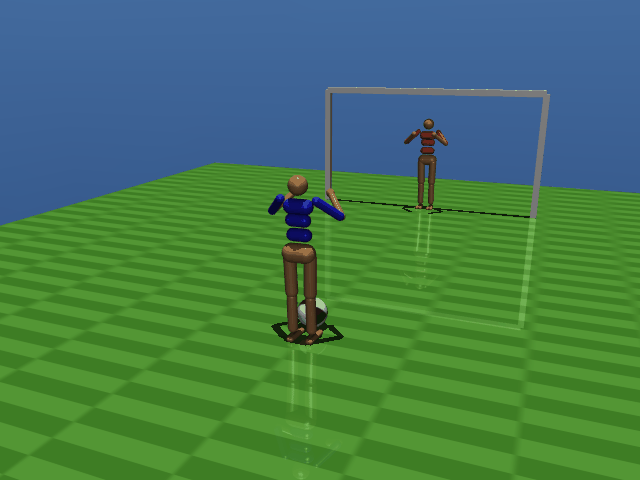

In [28]:
# ── Rollout: both trained policies ───────────────────────────────────────────

rollout_env = PenaltiesEnv(training="keeper", striker_fn=frozen_striker_fn)
jit_reset = jax.jit(rollout_env.reset)
jit_step = jax.jit(rollout_env.step)


@jax.jit
def keeper_policy_fn(obs):
    norm = normalize_obs(get_obs(obs, cfg_keeper.policy_obs_key), keeper_actor_stats)
    dist, _ = keeper_model(norm, norm)
    return dist.mode


key = jax.random.key(7)
state = jit_reset(key)
trajectory = [state]

for _ in range(500):
    action = keeper_policy_fn(state.obs)
    state = jit_step(state, action)
    trajectory.append(state)
    if float(state.done) > 0.5:
        break

total_goals = sum(float(s.metrics["goals"]) for s in trajectory)
total_reward = sum(float(s.reward) for s in trajectory)
print(f"Episode length: {len(trajectory)} steps")
print(f"Total reward:   {total_reward:.1f}")
print(f"Goals scored:   {total_goals:.0f}")

# ── Render GIF ────────────────────────────────────────────────────────────────

render_every = 2
frames = rollout_env.render(trajectory[::render_every], camera=0, height=480, width=640)
fps = int(1.0 / rollout_env.dt / render_every)

gif_path = "penalties.gif"
imageio.mimsave(gif_path, [np.uint8(f) for f in frames], fps=fps, loop=0)
print(f"Saved -> {gif_path}  ({len(frames)} frames @ {fps} fps)")

from IPython.display import Image

Image(gif_path)